PREPARATION + 1 LAYER OF PROTOCOL + CHSH 
=
QC
=

In [67]:
#here we set up libs and the enviroment overall

import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
from qiskit.visualization import plot_gate_map, plot_error_map

from qiskit.circuit import Parameter

from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator

from qiskit.transpiler import PassManager
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.transpiler.passes import TrivialLayout, FullAncillaAllocation, EnlargeWithAncilla, ApplyLayout
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
%matplotlib inline
import numpy as np 




In [68]:

QiskitRuntimeService.save_account(
    channel="", 
    token="",
    instance=""
    name="",
    overwrite=True

)

QiskitRuntimeService.save_account(
    channel="", 
    token="",
    instance=""
    name="",
    overwrite=True

)
#service=QiskitRuntimeService(name="Research_CVUT-eu")
#real_backend = service.backend("ibm_aachen")

service=QiskitRuntimeService(name="Research_CVUT-us")
real_backend = service.backend("ibm_kingston")
#real_backend = service.backend("ibm_kingston")


In [69]:
print(f"Connected to: {real_backend.name}")
print(f"Number of qubits: {real_backend.num_qubits}")
print(f"Status: {real_backend.status().status_msg}")

Connected to: ibm_kingston
Number of qubits: 156
Status: active


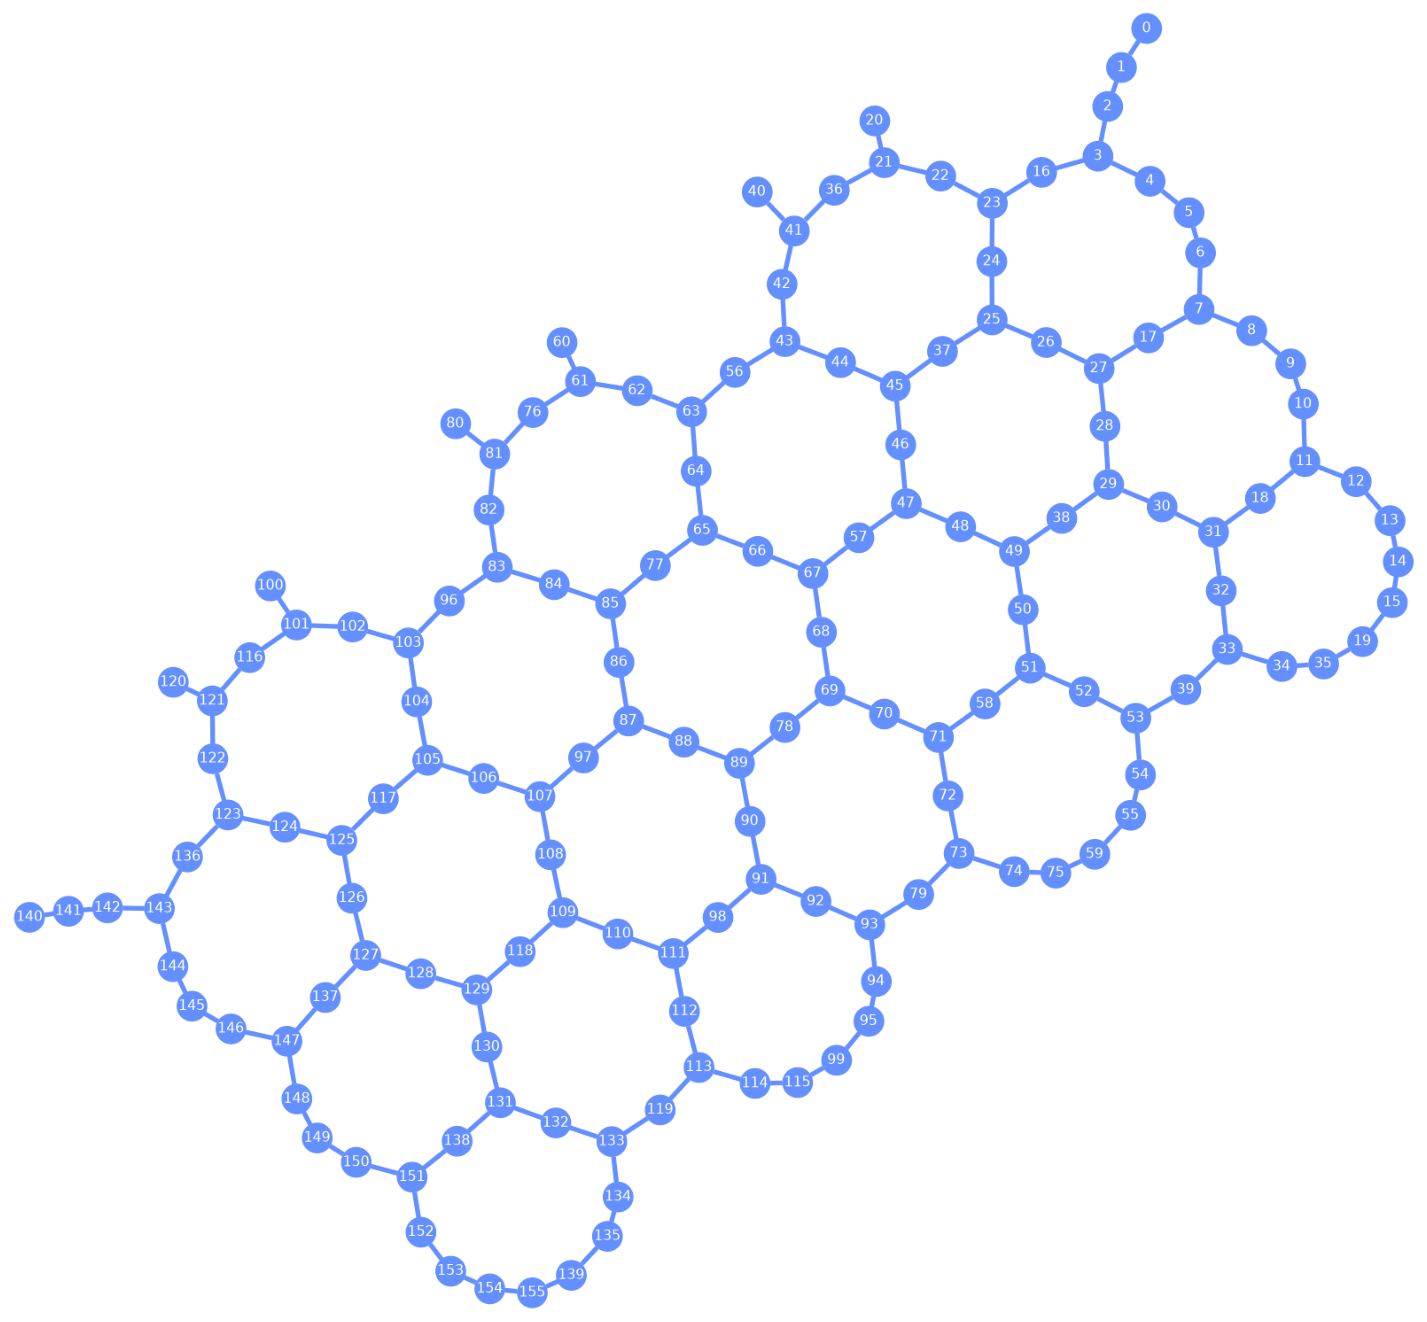

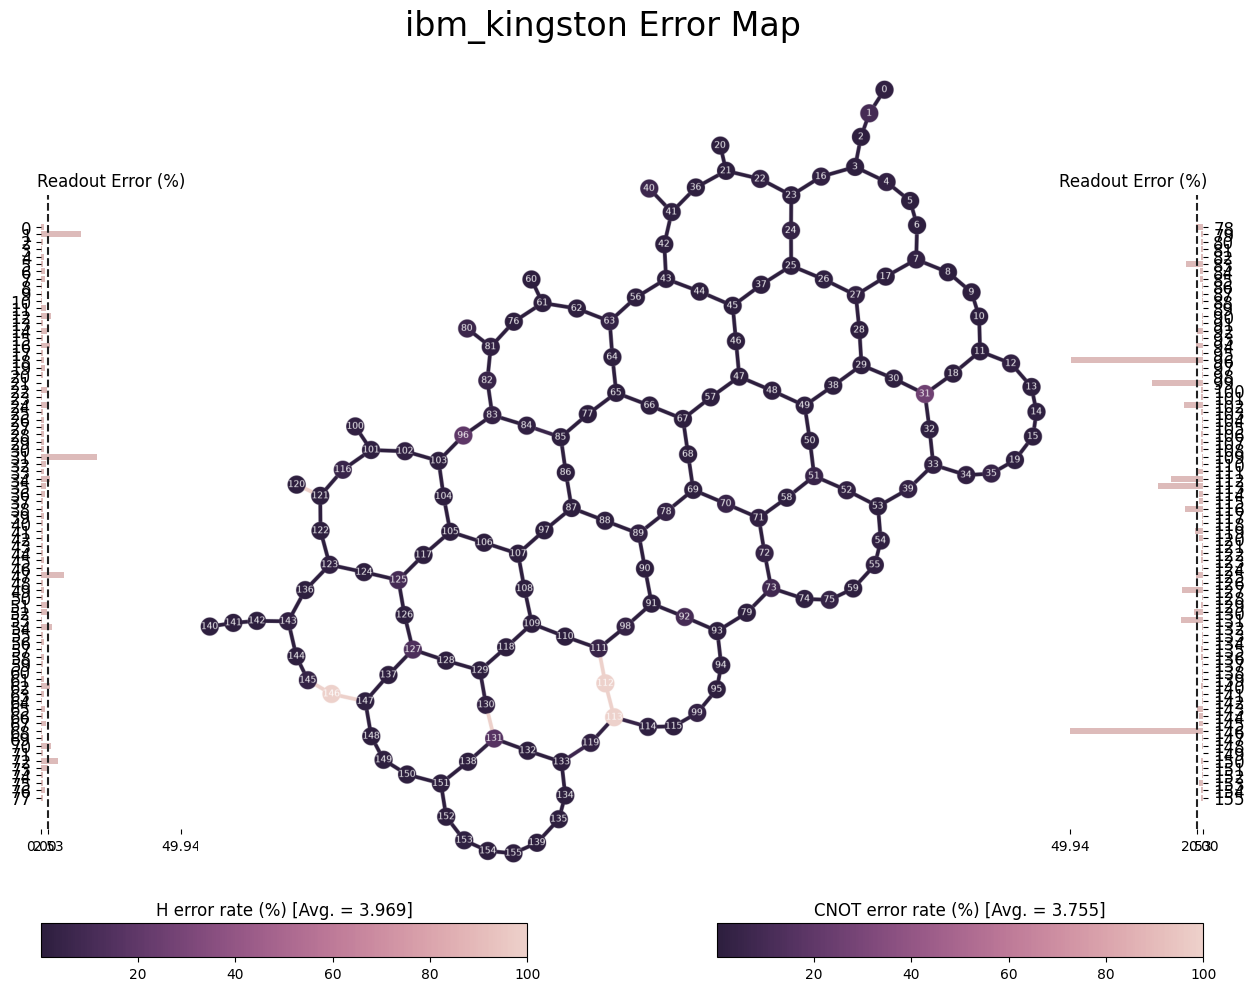

In [70]:
# Plot the physical connections (Topology)
plot_gate_map(real_backend)
plt.show()

# Plot a heat map of the gate errors across the whole chip
plot_error_map(real_backend)
plt.show()

In [71]:
#creating a circuit
q = QuantumRegister(21)
c_out = ClassicalRegister(2)
c_ps = ClassicalRegister(2)

qc = QuantumCircuit(q, c_out, c_ps)
angle_h = np.pi*1/(2)



In [72]:

#Torino
l1 = [42,43,44,45,46,55,65,64,63,62,61,54]
l2 = [46,47,48,49,50,56,69,68,67,66,65,55]

#Aachen
#l1 = [93,79,73,72,71,70,69,78,89,90,91,92]
#l2 = [71,58,51,50,49,40,47,57,67,68,69,70]

#fez
#l1 = [133,119,113,112,111,110,109,118,129,130,131,132]
#l2 = [111,98,91,90,89,88,87,97,107,108,109,110]



#fez
#l1 = [151,138,131,130,129,128,127,137,147,148,149,150]
#l2 = [129,118,109,108,107,106,105,117,125,126,127,128]





lists = [l1, l2]

initial_layout = []
seen = set()

for lst in lists:
    for x in lst:
        if x not in seen:
            initial_layout.append(x)
            seen.add(x)

print(initial_layout)

[93, 79, 73, 72, 71, 70, 69, 78, 89, 90, 91, 92, 58, 51, 50, 49, 40, 47, 57, 67, 68]


In [73]:
pm = generate_preset_pass_manager(
    backend=real_backend, 
    optimization_level=0, 
    initial_layout=initial_layout
)

In [74]:
transpiled_qc = pm.run(qc)


In [75]:



def protocol(q0, q1, q2, q3):
    qc.x(q1)
    qc.cx(q0, q1)
    qc.h(q0)

    qc.x(q3)
    qc.cx(q2, q3)
    qc.h(q2)
    
    
def measurement_ps(q1, q3, c0, c1):
    qc.measure(q1, c0)
    qc.measure(q3, c1)
    
def chsh (qc, q0, q1, c0, c1):

    settings = [
        ("A0B0", False, -np.pi/4),
        ("A0B1", False, -3*np.pi/4),
        ("A1B0", True, -np.pi/4),
        ("A1B1", True, -3*np.pi/4)
    ]
    results_E=[]

    for label, apply_h, ry_angle in settings:
        

        qc2= qc.copy()
        if apply_h:
            qc2.h(q0)


        qc2.ry(ry_angle, q1)
        qc2.measure(q0, c0)
        qc2.measure(q1, c1)
        


        sim = AerSimulator() 
        noisy_sim = AerSimulator.from_backend(real_backend)
        transpiled_qc = pm.run(qc2)


        job = noisy_sim.run(transpiled_qc, shots=10000)


        result = job.result()
        counts = result.get_counts()

        s00 = counts.get('00 00', 0)
        s11 = counts.get('00 11', 0)
        e01 = counts.get('00 01', 0)
        e10 = counts.get('00 10', 0)

        total = s00 + s11 + e01 + e10

        E = (s00 + s11 - e01 - e10) / total if total > 0 else 0
        results_E.append(E)

        print(f"Setting {label} | E = {E:.4f}")

        if len(results_E)==4:
            S = results_E[0] - results_E[1] + results_E[2] + results_E[3]
            print("\n" + "="*30)
            print(f"CHSH S-value: {S:.4f}")
            print("Violation?" , "YES" if abs(S) > 2 else "NO")
            print("="*30)
            t_qc.draw('mpl')
            plt.show()




We entangle qubits 42 with 56 and 54 with 69, then UUCDB, then CHSH on 42,56

In [76]:
#path 1 42 - 56
qc.h(q[0])
qc.cx(q[0], q[1])
qc.swap(q[1], q[2])
qc.swap(q[2], q[3])
qc.swap(q[3], q[4])
qc.swap(q[4], q[12])
qc.swap(q[12], q[13])
qc.swap(q[13], q[14])
qc.swap(q[14], q[15])
qc.swap(q[15], q[16])
qc.swap(q[16], q[17])
qc.swap(q[17], q[18])



#path 2 54 - 69
qc.h(q[11])
qc.cx(q[11], q[10])
qc.swap(q[10], q[9])
qc.swap(q[9], q[8])
qc.swap(q[8], q[7])
qc.swap(q[7], q[6])
qc.swap(q[6], q[20])
qc.swap(q[20], q[19])





Original Circuit:


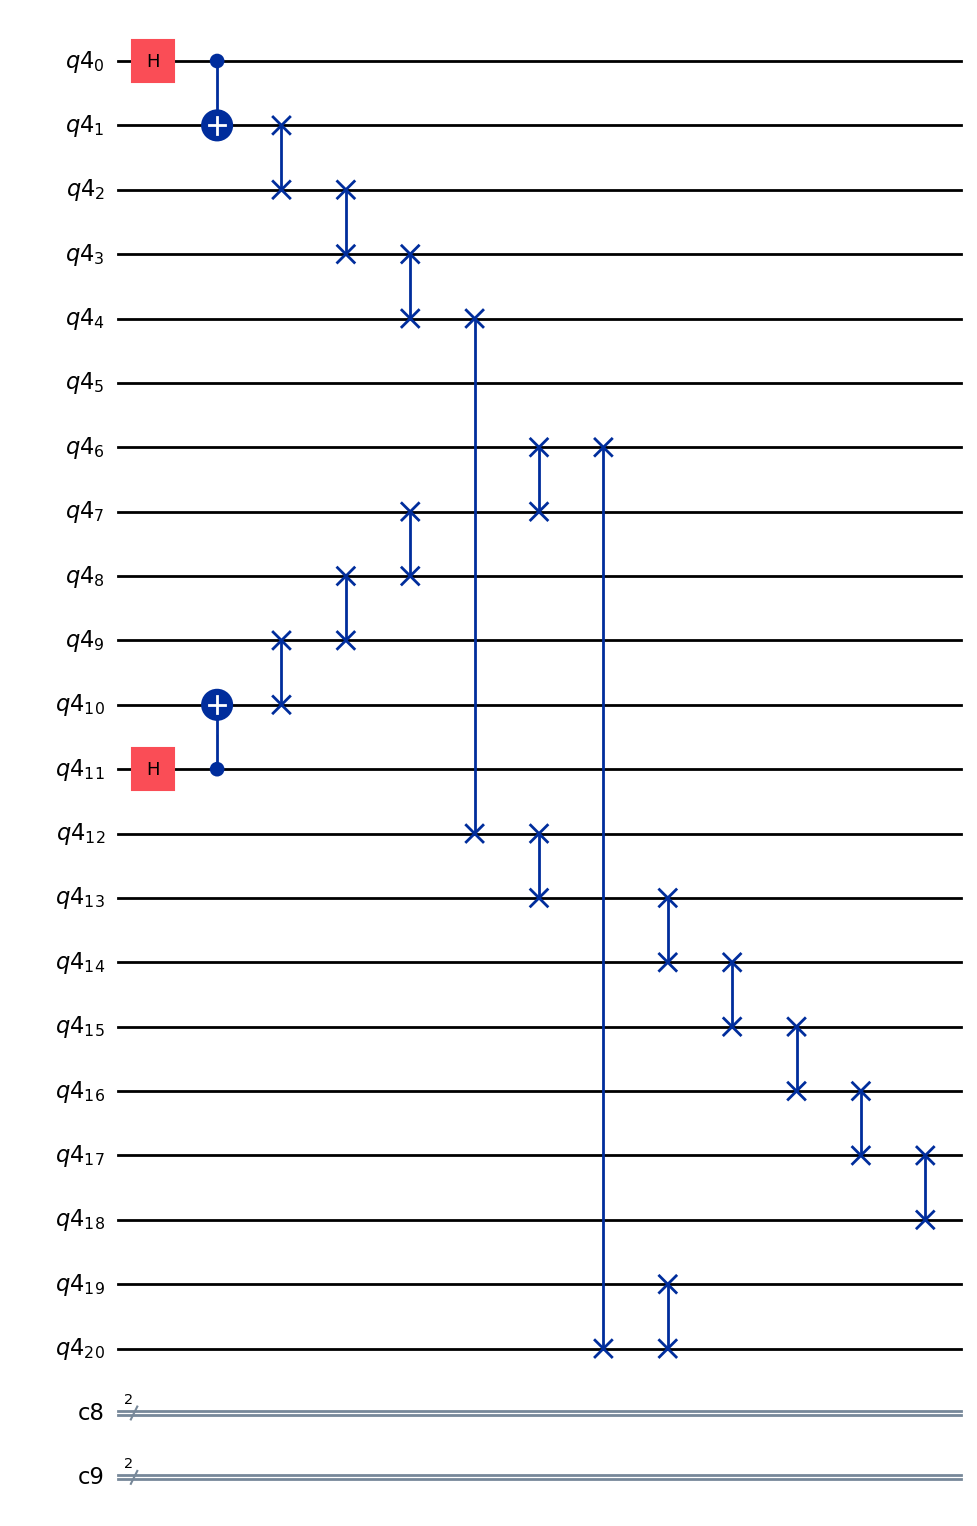

In [77]:
print("Original Circuit:")
qc.draw('mpl')
plt.show()

In [78]:
print(qc.num_qubits)
print(qc.depth())

21
12


In [79]:

protocol(q[0],q[11],q[18],q[19])
measurement_ps(q[0], q[18], c_ps[0], c_ps[1])
 

Setting A0B0 | E = 0.3066
Setting A0B1 | E = -0.3065
Setting A1B0 | E = 0.0273
Setting A1B1 | E = 0.0469

CHSH S-value: 0.6873
Violation? NO


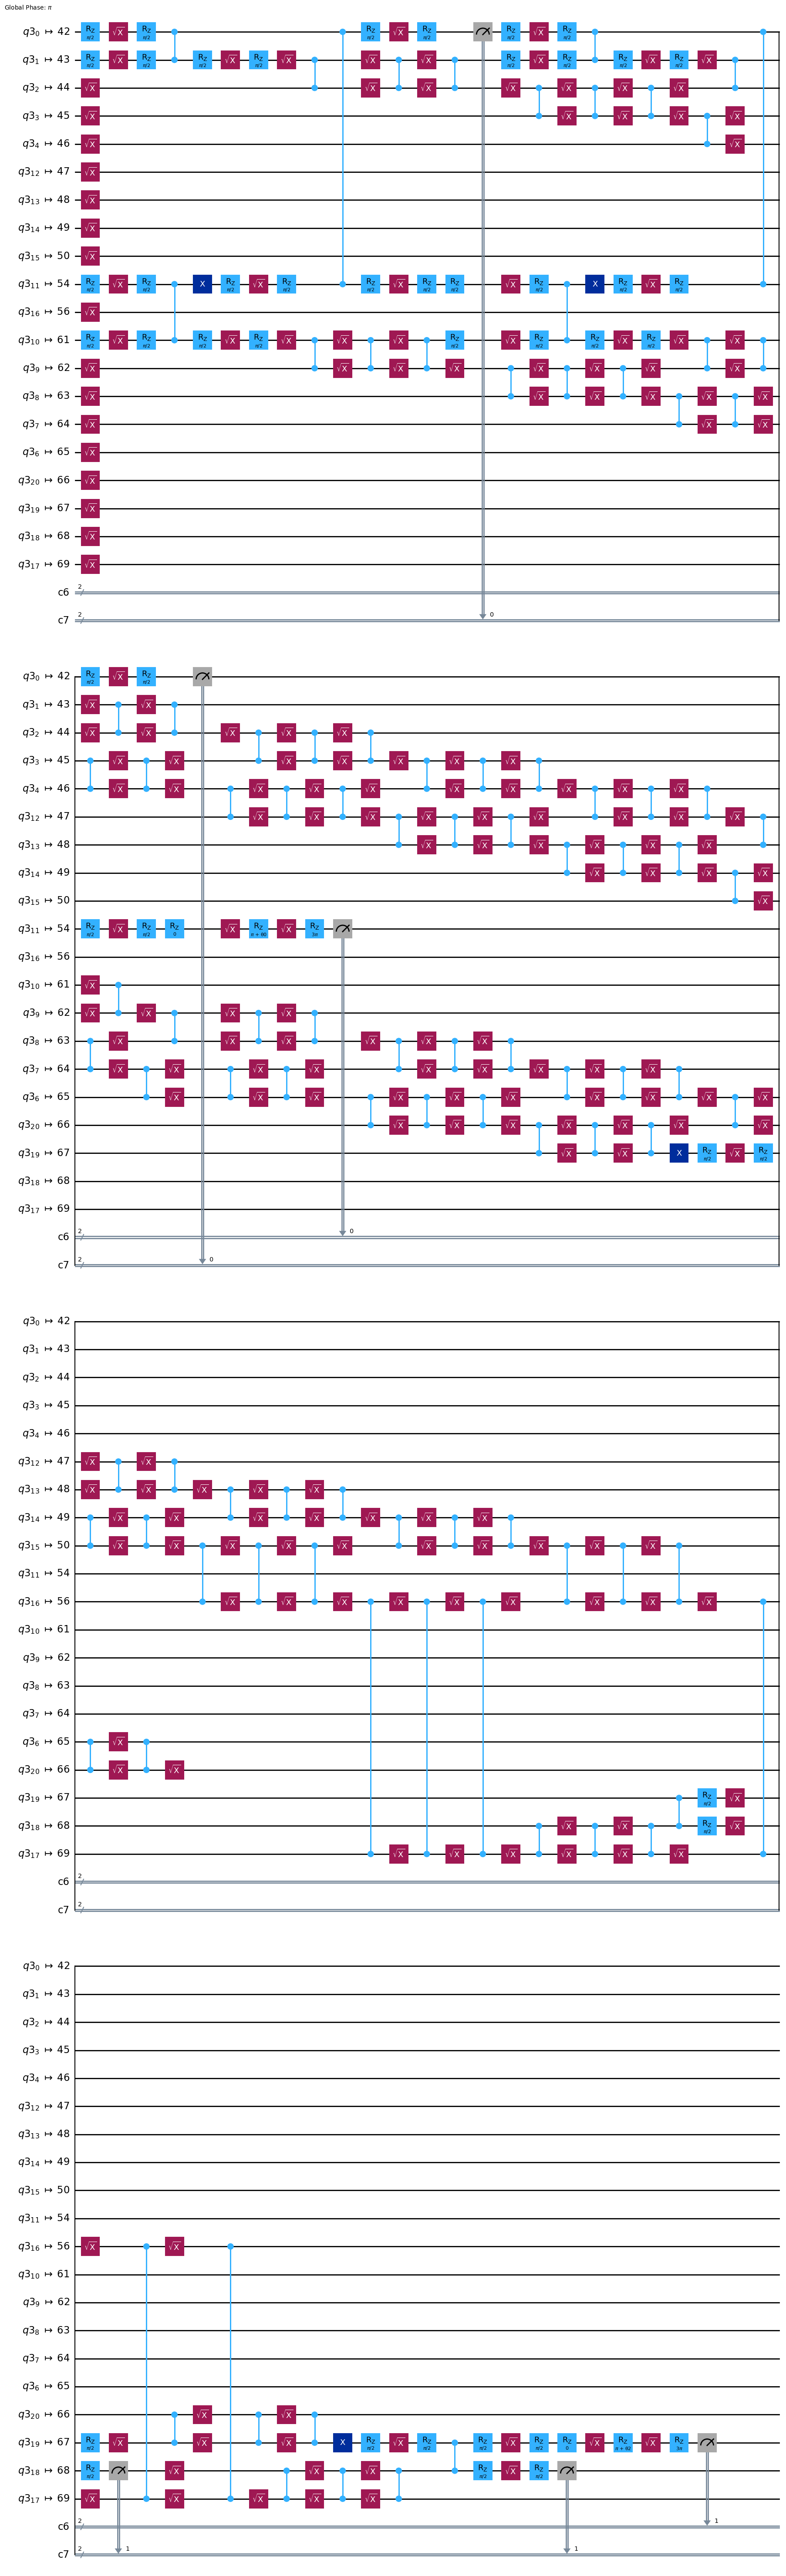

In [66]:
chsh(qc, q[11], q[19], c_out[0],c_out[1])
